# [ **StyleGAN-NADA-reimplementation-for-DLS-School**](https://github.com/F34723/StyleGAN-NADA-reimplementation-for-DLS-School)

In [ ]:
%%capture
!pip install ftfy regex tqdm ninja
!pip install git+https://github.com/openai/CLIP.git

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
import copy
from google.colab import drive
from huggingface_hub import hf_hub_download

In [ ]:
drive.mount('/content/drive')

seed = 48
torch.manual_seed(seed)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Mounted at /content/drive


In [ ]:
!git clone https://github.com/rosinality/stylegan2-pytorch.git

Cloning into 'stylegan2-pytorch'...
remote: Enumerating objects: 395, done.
remote: Total 395 (delta 0), reused 0 (delta 0), pack-reused 395 (from 1)
Receiving objects: 100% (395/395), 122.51 MiB | 42.31 MiB/s, done.
Resolving deltas: 100% (205/205), done.


In [ ]:
cd stylegan2-pytorch/

/content/stylegan2-pytorch


In [ ]:
auth.authenticate_user()

drive_service = build('drive', 'v3')

ids = ['1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT', '1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL']

for file_id in ids:
    file_metadata = drive_service.files().get(fileId=file_id).execute()
    filename = file_metadata['name']

    request = drive_service.files().get_media(fileId=file_id)

    with open(filename, 'wb') as f:
        downloader = MediaIoBaseDownload(f, request)
        done = False
        while not done:
            status, done = downloader.next_chunk()

    print(f"Успешно скачан файл: {filename}")

Успешно скачан файл: stylegan2-ffhq-config-f.pt
Успешно скачан файл: model_ir_se50.pth


In [ ]:
class CLIPLoss(torch.nn.Module):

    def __init__(self, model, clip_size=224):

        super(CLIPLoss, self).__init__()

        self.model = model
        self.clip_size = clip_size

    def forward(self, image, text):

        image = (image + 1.0) / 2.0
        image = F.interpolate(image, size=(self.clip_size, self.clip_size), mode='bicubic', align_corners=False)
        image_embeddings = self.model.encode_image(image)

        with torch.no_grad():
            text_embeddings = self.model.encode_text(text)

        image_embeddings = image_embeddings / (image_embeddings.norm(dim=-1, keepdim=True) + 1e-8)
        text_embeddings = text_embeddings / (text_embeddings.norm(dim=-1, keepdim=True) + 1e-8)

        cos_d = torch.matmul(image_embeddings, text_embeddings.t())
        similarity = (1.0 - cos_d).mean()

        return similarity

In [ ]:
class SGN2Nada_loss(nn.Module):
    def __init__(self, clip_model, text_source="a photo of a human", text_target="a photo of a werewolf", device="cuda"):
        super(SGN2Nada_loss, self).__init__()

        self.model = clip_model
        self.model.eval()
        self.model.requires_grad_(False)

        self.register_buffer("mean", torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1))

        with torch.no_grad():
            token_source = clip.tokenize(text_source).to(device)
            token_target = clip.tokenize(text_target).to(device)

            text_source_emb = self.model.encode_text(token_source)
            text_target_emb = self.model.encode_text(token_target)

            text_source_emb = text_source_emb / text_source_emb.norm(dim=-1, keepdim=True)
            text_target_emb = text_target_emb / text_target_emb.norm(dim=-1, keepdim=True)

            text_delta = text_target_emb - text_source_emb

            #self.register_buffer("text_delta", text_target_emb - text_source_emb)
            self.register_buffer("text_delta", text_delta / text_delta.norm(dim=-1, keepdim=True))

    def forward(self, img_frozen, img_trained):
        img_frozen = (img_frozen + 1.0) / 2.0
        img_trained = (img_trained + 1.0) / 2.0

        img_frozen = F.interpolate(img_frozen, size=(224, 224), mode='bicubic', align_corners=False)
        img_trained = F.interpolate(img_trained, size=(224, 224), mode='bicubic', align_corners=False)

        img_frozen = (img_frozen - self.mean) / self.std
        img_trained = (img_trained - self.mean) / self.std

        img_trained_emb = self.model.encode_image(img_trained)
        img_trained_emb = img_trained_emb / img_trained_emb.norm(dim=-1, keepdim=True)

        with torch.no_grad():
            img_frozen_emb = self.model.encode_image(img_frozen)
            img_frozen_emb = img_frozen_emb / img_frozen_emb.norm(dim=-1, keepdim=True)

        img_delta = img_trained_emb - img_frozen_emb
        img_delta = img_delta / img_delta.norm(dim=-1, keepdim=True)

        cos_d = F.cosine_similarity(img_delta, self.text_delta, dim=-1, eps=1e-8)

        loss = (1.0 - cos_d).mean()

        return loss


In [ ]:
clip_model_16, clip_preprocess = clip.load("ViT-B/16", device='cuda')
clip_model_32, clip_preprocess2 = clip.load("ViT-B/32", device='cuda')

clip_loss_v16 = CLIPLoss(clip_model_16)
clip_loss_v32 = CLIPLoss(clip_model_32)

100%|████████████████████████████████████████| 335M/335M [00:02<00:00, 145MiB/s]
100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 163MiB/s]


In [ ]:
from model import Generator

state_dict = torch.load('/content/stylegan2-pytorch/stylegan2-ffhq-config-f.pt', map_location=device)
latent_dim = 512

g_frozen = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
g_frozen.load_state_dict(state_dict['g_ema'])

g_frozen.eval()
g_frozen.requires_grad_(False)

print('Fine!')

Fine!


In [ ]:
def choose_k_best_parameters(g_frozen, text_target, loss1, loss2, k, device, n_steps=20, batch_size=4):

    diff_dict = {}

    latent_z_generated = torch.randn(batch_size, 512, device=device)

    with torch.no_grad():
        latent_w_original = g_frozen.get_latent(latent_z_generated).detach()

    num_layers = g_frozen.n_latent

    latent_w_original = latent_w_original.unsqueeze(1).repeat(1, num_layers, 1)

    duplicated_latent = latent_w_original.clone().requires_grad_(True)

    optimizer = torch.optim.Adam([duplicated_latent], lr=0.01)

    for _ in range(n_steps):

      optimizer.zero_grad()
      img = g_frozen([duplicated_latent], input_is_latent=True, randomize_noise=False)[0]

      loss_V16 = loss1(img, text_target)
      loss_V32 = loss2(img, text_target)

      loss_val = loss_V16 + loss_V32
      loss_val.backward()
      optimizer.step()

    for i in range(duplicated_latent.size(1)):
      with torch.no_grad():
          latent_diff = torch.mean(torch.abs(duplicated_latent[:, i, :] - latent_w_original[:, i, :])).item()
          diff_dict[i] = latent_diff

    sorted_diff_dict = dict(sorted(diff_dict.items(), key=lambda item: item[1], reverse=True))

    return list(sorted_diff_dict.keys())[:k]

## Код для тестирования гипотез, наблюдения за процессом обучения и оценки результатов

Step 299/300 | Loss: 1.2461 | LR: 0.00200


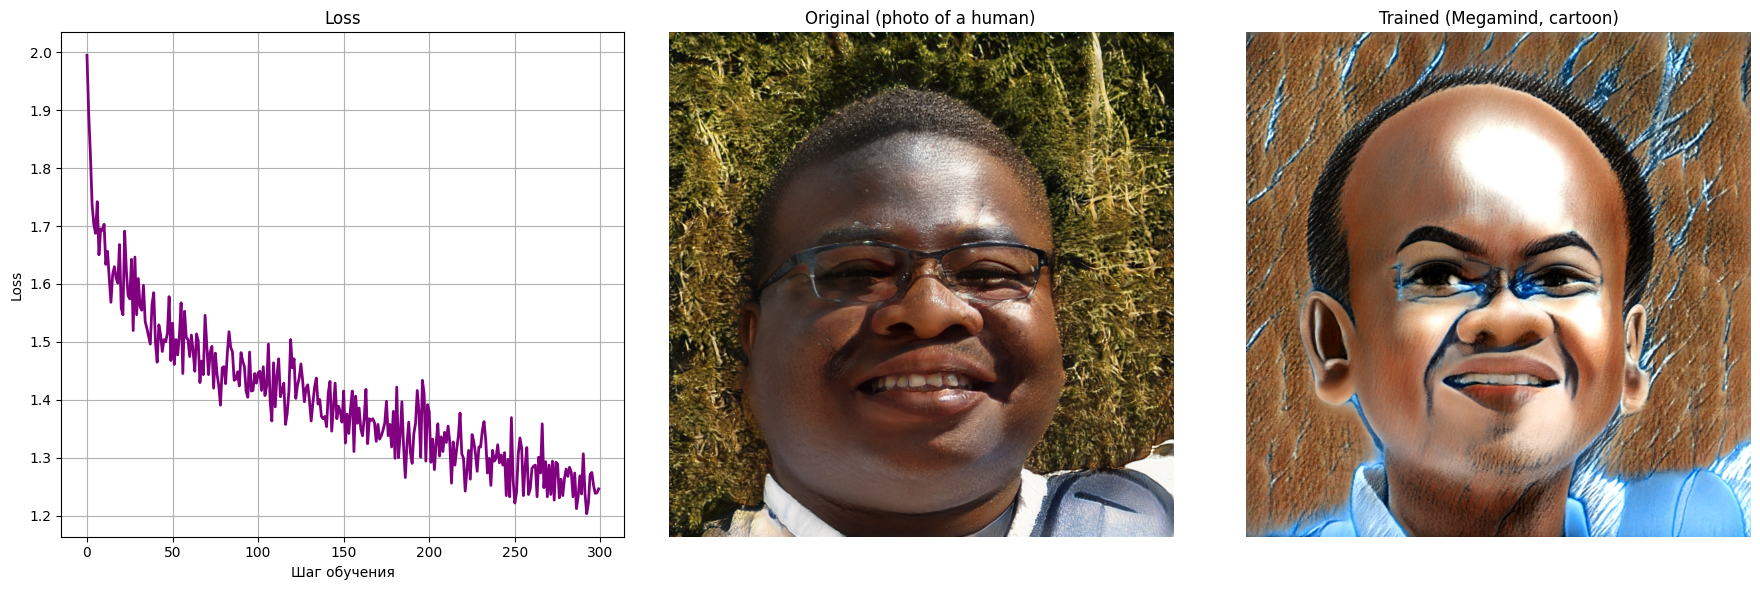

In [ ]:
text_target = 'Megamind, cartoon'
text_source = 'photo of a human'
num_steps = 300
N = 20
batch_size = 4

text_target_tokens = clip.tokenize([text_target]).to(device)
best_indicies = choose_k_best_parameters(g_frozen, text_target_tokens, clip_loss_v16, clip_loss_v32, 18, device)

g_trainable = copy.deepcopy(g_frozen)
g_trainable.train()
g_trainable.requires_grad_(True)

for param in g_trainable.parameters():
    param.requires_grad = False

style_modulations = [g_trainable.conv1, None] + list(g_trainable.convs)

for idx in best_indicies:
    layer = style_modulations[idx]
    if layer is not None:
        for name, param in layer.named_parameters():
            if 'affine' not in name and 'to_style' not in name and 'to_rgb' not in name:
                param.requires_grad = True

sgn2n_loss = SGN2Nada_loss(clip_model_16, text_source=text_source, text_target=text_target, device=device).to(device)
sgn2n_loss2 = SGN2Nada_loss(clip_model_32, text_source=text_source, text_target=text_target, device=device).to(device)

trainable_parameters = [p for p in g_trainable.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(trainable_parameters, lr=0.002, betas=(0.0, 0.99))
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)

losses = []
torch.cuda.empty_cache()

for step in range(num_steps):
    optimizer.zero_grad()
    latent_z_generated = torch.randn(batch_size, 512, device=device)

    with torch.no_grad():
        img_frozen, latent_w = g_frozen([latent_z_generated], input_is_latent=False, return_latents=True)

    img_trained = g_trainable([latent_w], input_is_latent=True, randomize_noise=False)[0]

    loss = sgn2n_loss(img_frozen, img_trained) + sgn2n_loss2(img_frozen, img_trained)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if step % N == 0 or step == num_steps - 1:
        clear_output(wait=True)
        print(f"Step {step:03d}/{num_steps} | Loss: {loss.item():.4f} | LR: {scheduler.get_last_lr()[0]:.5f}")

        with torch.no_grad():
            grid = torchvision.utils.make_grid(torch.cat([img_frozen, img_trained], dim=0), normalize=True, value_range=(-1, 1))
            torchvision.utils.save_image(grid, f"step_{step}.png")

            img_frozen_grid = (img_frozen[0].detach().cpu() + 1.0) / 2.0
            img_trained_grid = (img_trained[0].detach().cpu() + 1.0) / 2.0
            img_frozen_np = img_frozen_grid.permute(1, 2, 0).clamp(0, 1).numpy()
            img_trained_np = img_trained_grid.permute(1, 2, 0).clamp(0, 1).numpy()

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].plot(losses, color='purple', lw=2)
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Шаг обучения")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True)

        axes[1].imshow(img_frozen_np)
        axes[1].set_title(f"Original ({text_source})")
        axes[1].axis('off')

        axes[2].imshow(img_trained_np)
        axes[2].set_title(f"Trained ({text_target})")
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()


## Выгрузка весов модели

In [ ]:
params = {
    "Minecraft": {
        "source_text": "a photo of a person",
        "target_text": "a Minecraft cubic character model, iconic cubic head",
        "training_steps": 500,
        "lr": 0.002,
        "batch_size": 4,
        "k": 18
    },
    "Cinderella": {
        "source_text": "a photo of a person",
        "target_text": "Cinderella from cartoon, cute, beautiful",
        "training_steps": 350,
        "lr": 0.002,
        "batch_size": 4,
        "k": 18
    },
    "Emo": {
        "source_text": "a photo of a person",
        "target_text": "a photo of a sad Emo person",
        "training_steps": 300,
        "lr": 0.002,
        "batch_size": 4,
        "k": 12
    },
    "Megamind": {
        "source_text": "a photo of a person",
        "target_text": "Megamind, cartoon",
        "training_steps": 300,
        "lr": 0.002,
        "batch_size": 4,
        "k": 18
    },
    "Whitewalker": {
        "source_text": "a photo of a person",
        "target_text": "Whitewalker",
        "training_steps": 500,
        "lr": 0.002,
        "batch_size": 4,
        "k": 18
    },
    "Sketch": {
        "source_text": "a photo of a person",
        "target_text": "a black and white pencil sketch drawing, hand-drawn art",
        "training_steps": 300,
        "lr": 0.002,
        "batch_size": 4,
        "k": 14
    },
    "Anime": {
        "source_text": "a photo of a person",
        "target_text": "anime character, Japanese animation style, cel-shaded art",
        "training_steps": 400,
        "lr": 0.002,
        "batch_size": 4,
        "k": 18
    },
    "Mona Lisa": {
        "source_text": "a photo of a person",
        "target_text": "the Mona Lisa oil painting by Leonardo da Vinci, classical renaissance art style",
        "training_steps": 350,
        "lr": 0.002,
        "batch_size": 4,
        "k": 16
    }
}


In [ ]:
def prepare_model_for_style(g_source, best_indices):
    g_trainable = copy.deepcopy(g_source)

    for param in g_trainable.parameters():
        param.requires_grad = False

    style_modulations = [g_trainable.conv1, None]
    for conv_layer in g_trainable.convs:
        style_modulations.append(conv_layer)

    for idx in best_indices:
        layer = style_modulations[idx]
        if layer is not None:
            for name, param in layer.named_parameters():
                if 'affine' not in name and 'to_style' not in name and 'to_rgb' not in name:
                    param.requires_grad = True

    return g_trainable


def style_gan_nada_training(g_trainable, g_frozen, text_source, text_target, lr, device, num_steps, batch_size):
    sgn2n_loss = SGN2Nada_loss(clip_model_16, text_source=text_source, text_target=text_target, device=device).to(device)
    sgn2n_loss2 = SGN2Nada_loss(clip_model_32, text_source=text_source, text_target=text_target, device=device).to(device)

    trainable_parameters = [p for p in g_trainable.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_parameters, lr=lr, betas=(0.0, 0.99))

    torch.cuda.empty_cache()

    for step in range(num_steps):
        optimizer.zero_grad()

        latent_z_generated = torch.randn(batch_size, 512, device=device)

        with torch.no_grad():
            img_frozen, latent_w = g_frozen([latent_z_generated], input_is_latent=False, return_latents=True)

        img_trained = g_trainable([latent_w], input_is_latent=True, randomize_noise=False)[0]

        loss1 = sgn2n_loss(img_frozen, img_trained)
        loss2 = sgn2n_loss2(img_frozen, img_trained)
        loss = loss1 + loss2

        loss.backward()
        optimizer.step()

    return g_trainable.state_dict()

In [ ]:
base_output_dir = "/content/drive/MyDrive/DLS/Project/weights"

for style_name, config in params.items():
    text_target_tokens = clip.tokenize([config['target_text']]).to(device)

    best_indices = choose_k_best_parameters(
        g_frozen=g_frozen,
        text_target=text_target_tokens,
        loss1=clip_loss_v16,
        loss2=clip_loss_v32,
        k=config['k'],
        device=device
    )

    g_style_trainable = prepare_model_for_style(g_frozen, best_indices)

    style_weights = style_gan_nada_training(
        g_trainable=g_style_trainable,
        g_frozen=g_frozen,
        text_source=config['source_text'],
        text_target=config['target_text'],
        lr=config['lr'],
        device=device,
        num_steps=config['training_steps'],
        batch_size=config['batch_size']
    )

    output_path = os.path.join(base_output_dir, f"{style_name.lower()}.pt")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    checkpoint = {
        "state_dict": style_weights,
        "best_indices": best_indices,
        "style_name": style_name,
        "text_source": config['source_text'],
        "text_target": config['target_text'],
        "num_steps": config['training_steps'],
        "batch_size": config['batch_size'],
        "lr": config['lr']
    }

    torch.save(checkpoint, output_path)

print("Done!")


Done!


## Формирование картинок для главной страницы на GitHub

In [ ]:
repo_id = "F34723/stylegan2-nada-weights"
output_dir = "./github_showcase_strips"
os.makedirs(output_dir, exist_ok=True)

styles = ["minecraft", "emo", "megamind", "whitewalker", "sketch", "anime", "mona lisa"]
state_dict_path = '/content/stylegan2-pytorch/stylegan2-ffhq-config-f.pt'

g_frozen = Generator(size=1024, style_dim=512, n_mlp=8).to(device)
g_frozen.load_state_dict(torch.load(state_dict_path, map_location=device)['g_ema'])
g_frozen.eval().requires_grad_(False)

style_generators = {}
for style_name in styles:
    try:
        filename = f"{style_name}.pt"
        weights_path = hf_hub_download(repo_id=repo_id, filename=filename)
        checkpoint = torch.load(weights_path, map_location=device)

        g_inference = copy.deepcopy(g_frozen)
        g_inference.load_state_dict(checkpoint["state_dict"])
        g_inference.eval().requires_grad_(False)

        style_generators[style_name] = g_inference
    except Exception:
        continue

num_images = 10
for i in range(num_images):
    torch.manual_seed(100 + i)
    latent_z = torch.randn(1, 512, device=device)

    with torch.no_grad():
        img_original, latent_w = g_frozen([latent_z], input_is_latent=False, return_latents=True)
        strip_images = [img_original]

        for style_name in styles:
            if style_name in style_generators:
                img_styled = style_generators[style_name]([latent_w], input_is_latent=True, randomize_noise=False)[0]
                strip_images.append(img_styled)

        grid_strip = torchvision.utils.make_grid(
            torch.cat(strip_images, dim=0),
            nrow=len(strip_images),
            normalize=True,
            value_range=(-1, 1),
            padding=6,
            pad_value=1.0
        )

    out_name = f"person_{i+1}_all_styles.png"
    torchvision.utils.save_image(grid_strip, os.path.join(output_dir, out_name))


In [ ]:
from google.colab import files

img_dir = "./github_showcase_strips"
for f in os.listdir(img_dir):
    if f.endswith(".png"):
        p = os.path.join(img_dir, f)
        with Image.open(p) as img:
            img.convert("RGB").save(p, "JPEG", quality=75)

!zip -r /content/github_showcase_strips_light.zip ./github_showcase_strips
files.download('/content/github_showcase_strips_light.zip')

  adding: github_showcase_strips/ (stored 0%)
  adding: github_showcase_strips/person_10_all_styles.png (deflated 1%)
  adding: github_showcase_strips/person_5_all_styles.png (deflated 1%)
  adding: github_showcase_strips/person_7_all_styles.png (deflated 1%)
  adding: github_showcase_strips/person_6_all_styles.png (deflated 1%)
  adding: github_showcase_strips/person_1_all_styles.png (deflated 1%)
  adding: github_showcase_strips/person_9_all_styles.png (deflated 0%)
  adding: github_showcase_strips/person_2_all_styles.png (deflated 0%)
  adding: github_showcase_strips/.ipynb_checkpoints/ (stored 0%)
  adding: github_showcase_strips/person_4_all_styles.png (deflated 0%)
  adding: github_showcase_strips/person_3_all_styles.png (deflated 1%)
  adding: github_showcase_strips/person_8_all_styles.png (deflated 1%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>